# 🚗 Auto Imports Price Prediction

## Introduction

Car pricing depends on multiple factors such as engine performance, fuel efficiency, size, and brand.
This project aims to analyze the Auto Imports dataset and build predictive models to understand how car prices vary with different attributes.

## Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [43]:
df = pd.read_csv(r"C:\Users\NILESH\Downloads\auto_imports.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Assign Column Names

In [44]:
df.columns = [
    "symboling",
    "normalized-losses",
    "make",
    "fuel-type",
    "aspiration",
    "num-of-doors",
    "body-style",
    "drive-wheels",
    "engine-location",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-type",
    "num-of-cylinders",
    "engine-size",
    "fuel-system",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

In [45]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
197,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
198,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
199,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


## Basic Data Exploration

In [46]:
df.shape

(201, 26)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [48]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


## Handle Missing Values

In [49]:
df.replace("?", np.nan, inplace=True)

In [50]:
df.head(2)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500


## Convert Numeric Columns

In [51]:
numeric_cols = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

In [52]:
df[numeric_cols].dtypes

normalized-losses    float64
bore                 float64
stroke               float64
horsepower           float64
peak-rpm             float64
price                  int64
dtype: object

## Impute Missing Values

In [53]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [54]:
df.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

* Median is used for numerical columns to reduce outlier impact.
* Mode is used for categorical columns to keep category consistency.

## Exploratory Data Analysis (EDA)

### Price Distribution

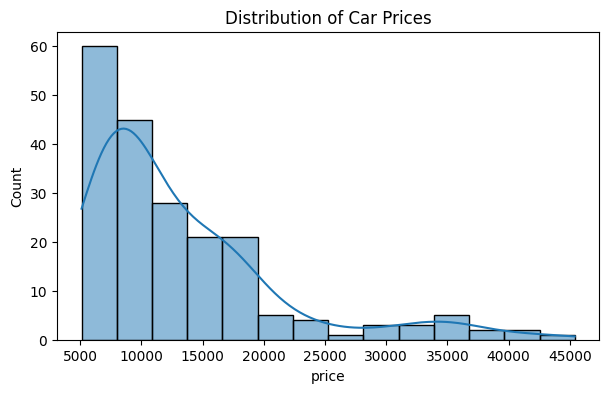

In [55]:
plt.figure(figsize=(7,4))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of Car Prices")
plt.show()

Most cars are priced in the low to mid range. A small number of expensive cars create a right-skewed distribution.

### Engine Size vs Price

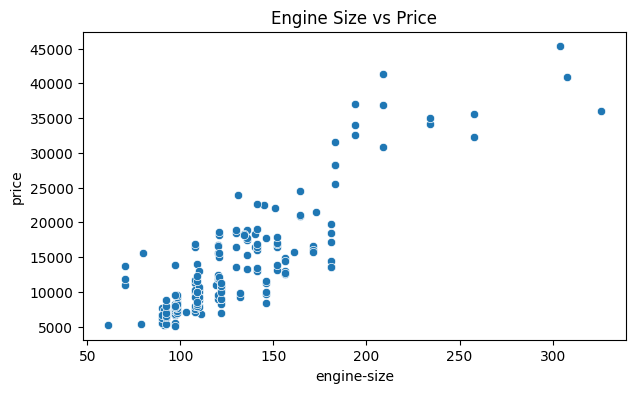

In [56]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=df["engine-size"], y=df["price"])
plt.title("Engine Size vs Price")
plt.show()

As engine size increases, the price also increases. This shows that engine size is a strong factor influencing car prices.

### Horsepower vs Price

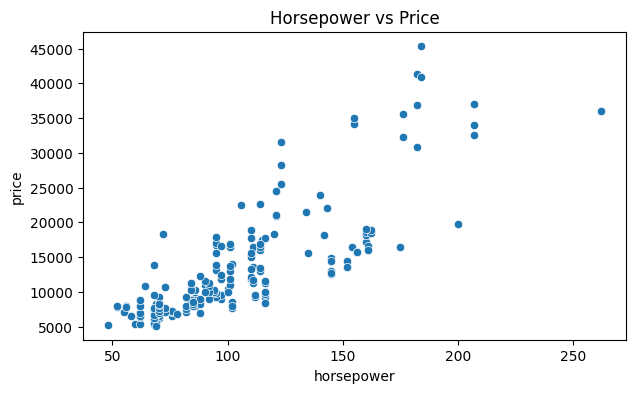

In [57]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=df["horsepower"], y=df["price"])
plt.title("Horsepower vs Price")
plt.show()

Cars with higher horsepower tend to be more expensive. This indicates that performance plays a major role in determining car prices.

### Correlation Heatmap

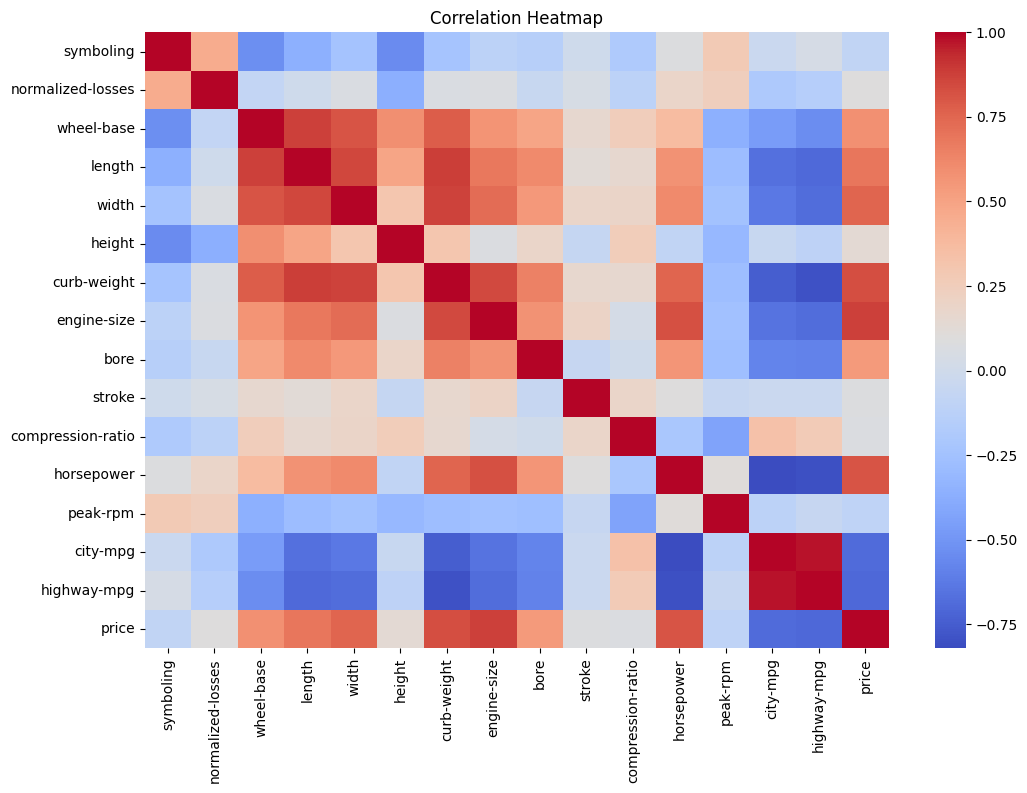

In [58]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Price is highly correlated with engine size, horsepower, curb weight, and width.

## Feature and Target Separation

In [59]:
X = df.drop("price", axis=1)
y = df["price"]

In [60]:
print(X.columns)
print(y.name)

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg'],
      dtype='object')
price


In [61]:
print(X.shape)
print(y.shape)

(201, 25)
(201,)


In [62]:
X.head()
y.head()

0    13495
1    16500
2    16500
3    13950
4    17450
Name: price, dtype: int64

In [63]:
type(X)
type(y)

pandas.core.series.Series

## Train Test Split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [65]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 25), (41, 25), (160,), (41,))

In [66]:
X_train.index.intersection(X_test.index)

Index([], dtype='int64')

## Data Preprocessing Pipeline

In [67]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),("num", "passthrough", numeric_cols)])

In [68]:
categorical_cols, numeric_cols

(Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
        'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
        'fuel-system'],
       dtype='object'),
 Index(['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
        'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
        'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
        'highway-mpg'],
       dtype='object'))

In [69]:
preprocessor

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')),
                                ('num', 'passthrough',
                                 Index(['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg'],
      dtype='object'))])

In [70]:
preprocessor.fit_transform(X).shape

(201, 74)

## Model Evaluation Function

In [71]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    return r2, mae, rmse

## Linear Regression Model

In [72]:
lr_model = Pipeline(steps=[("preprocessor", preprocessor),("model", LinearRegression())])

lr_model.fit(X_train, y_train)
lr_results = evaluate_model(lr_model, X_test, y_test)

In [73]:
lr_results

(0.9133797044850349, 1974.732083601297, np.float64(3255.4129752958966))

## Decision Tree Regressor

In [74]:
dt_model = Pipeline(steps=[("preprocessor", preprocessor),("model", DecisionTreeRegressor(random_state = 42))])

dt_model.fit(X_train, y_train)
dt_results = evaluate_model(dt_model, X_test, y_test)

In [75]:
dt_results

(0.9280246984675699, 1995.9878048780488, np.float64(2967.481404178692))

## Random Forest Regressor

In [76]:
rf_model = Pipeline(steps=[("preprocessor", preprocessor),("model", RandomForestRegressor(n_estimators = 200, random_state = 42))])

rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test)

In [77]:
rf_results

(0.9326097798857068, 1838.2195772357725, np.float64(2871.4066184216895))

## Model Comparison

In [78]:
results = pd.DataFrame({"Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [lr_results[0], dt_results[0], rf_results[0]],
    "MAE": [lr_results[1], dt_results[1], rf_results[1]],
    "RMSE": [lr_results[2], dt_results[2], rf_results[2]]})

In [79]:
results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.913380,1974.732084,3255.412975
1,Decision Tree,0.928025,1995.987805,2967.481404
2,Random Forest,0.932610,1838.219577,2871.406618


## Best Model Recommendation

In [80]:
results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
2,Random Forest,0.932610,1838.219577,2871.406618
1,Decision Tree,0.928025,1995.987805,2967.481404
0,Linear Regression,0.913380,1974.732084,3255.412975


The Random Forest model is the best model. It has the highest accuracy, the lowest error, handles complex relationships well, and is suitable for real-world use.

## Challenges Faced and Solutions

**Missing Values**

* Issue: Data contained "?"
* Solution: Median and mode imputation

**Categorical Data**

* Issue: ML models cannot read text
* Solution: One Hot Encoding

**Overfitting**

* Issue: Decision Tree overfitting
* Solution: Random Forest ensemble model

## Conclusion

* Engine size, horsepower, and curb weight have a strong impact on the price of a car.
* Cars with higher fuel efficiency are generally priced lower.
* The Random Forest model performs better than the other models used in this analysis.
* This model can help management plan effective pricing and make better design and business decisions.